In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
corpus='''A recurrent neural network (RNN) is a deep learning
model that is trained to process and convert a sequential data
input into a specific sequential data output. Sequential data
is data—such as words, sentences, or time-series data—where
sequential components interrelate based on complex semantics
and syntax rules. An RNN is a software system that consists
of many interconnected components mimicking how humans
perform sequential data conversions, such as translating
text from one language to another. RNNs are largely
being replaced by transformer-based artificial
intelligence (AI) and large language models (LLM),
which are much more efficient in sequential data processing.'''

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 76
X shape: (89, 10)
y shape: (89,)


In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, validation_split=0.2, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


In [ ]:
print("Final Training Loss:", rnn_history.history['loss'][-1])
print("Final Training Accuracy:", rnn_history.history['accuracy'][-1])
print("Validation Accuracy:", rnn_history.history['val_accuracy'][-1])
print("Validation Loss:", rnn_history.history['val_loss'][-1])

Final Training Loss: 0.6448106169700623
Final Training Accuracy: 0.9436619877815247
Validation Accuracy: 0.0
Validation Loss: 6.076518535614014


RNN model 2

In [ ]:
rnn_model2 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model2.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history2 = rnn_model2.fit(X, y, epochs=200, validation_split=0.2, verbose=0)
print("Vanilla RNN model 2 training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN model 2 training completed


In [ ]:
print("Final Training Loss:", rnn_history2.history['loss'][-1])
print("Final Training Accuracy:", rnn_history2.history['accuracy'][-1])
print("Validation Accuracy:", rnn_history2.history['val_accuracy'][-1])
print("Validation Loss:", rnn_history2.history['val_loss'][-1])

Final Training Loss: 0.017768511548638344
Final Training Accuracy: 1.0
Validation Accuracy: 0.0
Validation Loss: 6.564930438995361


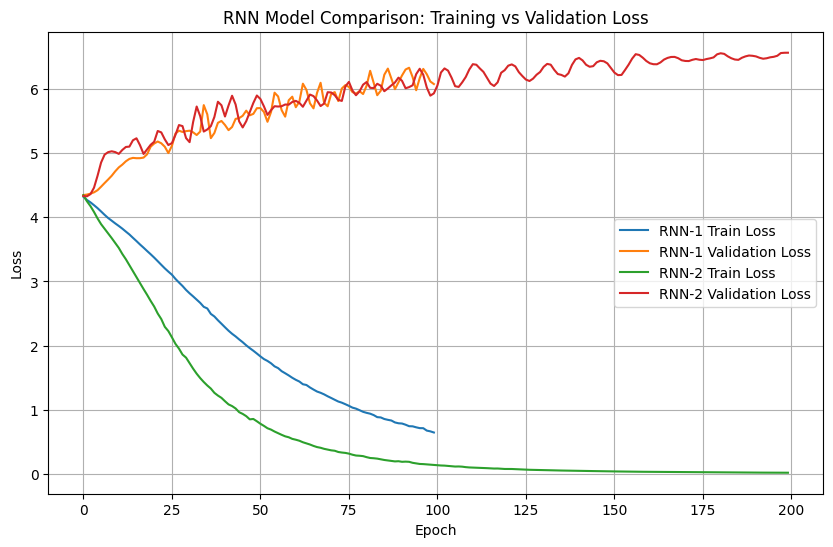

In [ ]:
plt.figure(figsize=(10,6))

# RNN Model 1
plt.plot(rnn_history.history['loss'], label='RNN-1 Train Loss')
plt.plot(rnn_history.history['val_loss'], label='RNN-1 Validation Loss')

# RNN Model 2
plt.plot(rnn_history2.history['loss'], label='RNN-2 Train Loss')
plt.plot(rnn_history2.history['val_loss'], label='RNN-2 Validation Loss')

plt.title("RNN Model Comparison: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

LSTM

In [ ]:
lstm_model1 = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model1.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history1 = lstm_model1.fit(X, y, epochs=100, validation_split=0.2, verbose=0)
print("LSTM training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM training completed


In [ ]:
print("Final Training Loss:", lstm_history1.history['loss'][-1])
print("Final Training Accuracy:", lstm_history1.history['accuracy'][-1])
print("Validation Accuracy:", lstm_history1.history['val_accuracy'][-1])
print("Validation Loss:", lstm_history1.history['val_loss'][-1])

Final Training Loss: 1.894776701927185
Final Training Accuracy: 0.6478873491287231
Validation Accuracy: 0.0
Validation Loss: 7.44788932800293


LSTM model 2

In [ ]:
lstm_model_2 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model_2.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history_2 = lstm_model_2.fit(X, y, epochs=200, validation_split=0.2, verbose=0)
print("LSTM model 2 training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM model 2 training completed


In [ ]:
print("Final Training Loss:", lstm_history_2.history['loss'][-1])
print("Final Training Accuracy:", lstm_history_2.history['accuracy'][-1])
print("Validation Accuracy:", lstm_history_2.history['val_accuracy'][-1])
print("Validation Loss:", lstm_history_2.history['val_loss'][-1])

Final Training Loss: 0.13068243861198425
Final Training Accuracy: 1.0
Validation Accuracy: 0.0555555559694767
Validation Loss: 9.075486183166504


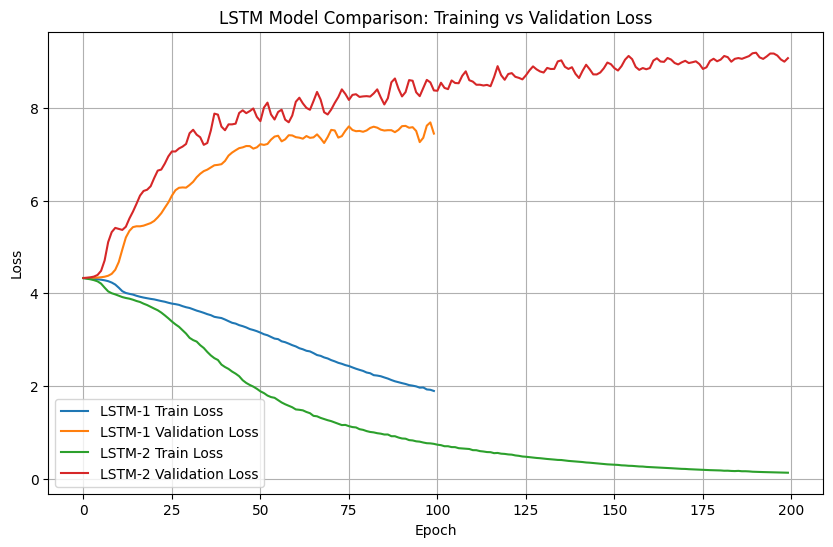

In [ ]:
plt.figure(figsize=(10,6))

# LSTMModel 1
plt.plot(lstm_history1.history['loss'], label='LSTM-1 Train Loss')
plt.plot(lstm_history1.history['val_loss'], label='LSTM-1 Validation Loss')

# LSTM Model 2
plt.plot(lstm_history_2.history['loss'], label='LSTM-2 Train Loss')
plt.plot(lstm_history_2.history['val_loss'], label='LSTM-2 Validation Loss')

plt.title("LSTM Model Comparison: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

GRU model

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, validation_split=0.2, verbose=0)
print("GRU training completed")

GRU training completed


In [ ]:
print("Final Training Loss:", gru_history.history['loss'][-1])
print("Final Training Accuracy:", gru_history.history['accuracy'][-1])
print("Validation Accuracy:", gru_history.history['val_accuracy'][-1])
print("Validation Loss:", gru_history.history['val_loss'][-1])

Final Training Loss: 0.8375216126441956
Final Training Accuracy: 0.98591548204422
Validation Accuracy: 0.0
Validation Loss: 7.798917770385742


In [ ]:
gru_model1 = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model1.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history1 = gru_model1.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU training completed


In [ ]:
print("Final Training Loss:", gru_history1.history['loss'][-1])
print("Final Training Accuracy:", gru_history1.history['accuracy'][-1])

Final Training Loss: 0.6497118473052979
Final Training Accuracy: 1.0


GRU model 2

In [ ]:
gru_model2 = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model2.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history2 = gru_model2.fit(X, y, epochs=200, validation_split=0.2, verbose=0)
print("GRU model 2 training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


GRU model 2 training completed


In [ ]:
print("Final GRU model 2 Training Loss:", gru_history2.history['loss'][-1])
print("Final GRU model 2 Training Accuracy:", gru_history2.history['accuracy'][-1])
print("GRU model 2 Validation Accuracy:", gru_history2.history['val_accuracy'][-1])
print("GRU model 2 Validation Loss:", gru_history2.history['val_loss'][-1])

Final GRU model 2 Training Loss: 0.02221078984439373
Final GRU model 2 Training Accuracy: 1.0
GRU model 2 Validation Accuracy: 0.0
GRU model 2 Validation Loss: 9.716906547546387


Comparison graph

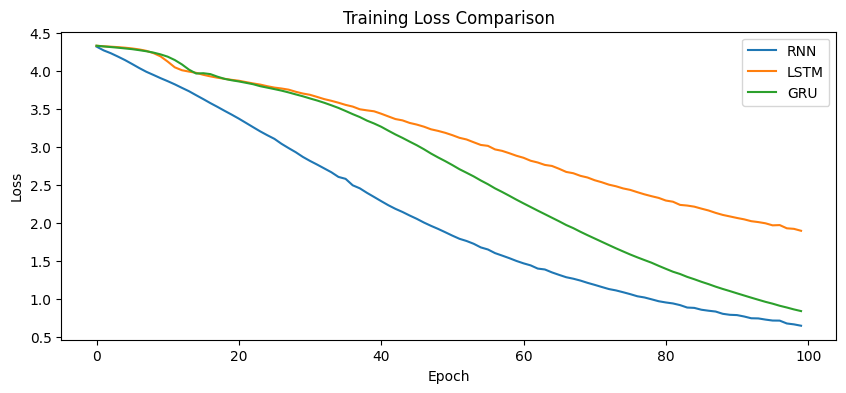

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history1.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

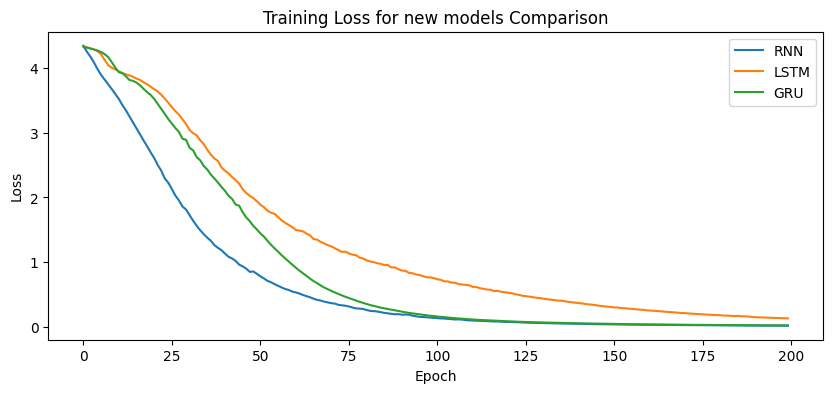

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history2.history['loss'], label='RNN')
plt.plot(lstm_history_2.history['loss'], label='LSTM')
plt.plot(gru_history2.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss for new models Comparison")
plt.legend()
plt.show()

Generating words

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model1, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning many interconnected to mimicking how humans data sequential data output
LSTM: deep learning components components on complex complex semantics largely data—where perform perform
GRU : deep learning components interrelate on complex semantics semantics series data—where data—where data—where


In [ ]:
print("RNN :", generate_text(rnn_model2, "deep learning", 5))
print("LSTM:", generate_text(lstm_model_2, "deep learning", 5))
print("GRU :", generate_text(gru_model2, "deep learning", 5))

RNN : deep learning components interrelate based on complex
LSTM: deep learning data—such as words or time
GRU : deep learning as words sentences or time


In [ ]:
print("RNN :", generate_text(rnn_model2, "deep learning", 10))
print("LSTM:", generate_text(lstm_model_2, "deep learning", 10))
print("GRU :", generate_text(gru_model2, "deep learning", 10))

RNN : deep learning components interrelate based on complex semantics learning that consists process
LSTM: deep learning data—such as words or time series data—where data—where data—where data—where
GRU : deep learning as words sentences or time series data—where sequential data conversions
